## Confirmatory data analysis

- ordinal logistic regression `cgpa ~ stress_z_score + anxiety_z_score + depression_z_score`
- ordinal logistic regression with control variables `+ department + academic_year + gender`
- separate adjusted ordinal models (one condition at a time)
- multicollinearity diagnostic (VIF)
- pca-based latent distress model
- one-way ANOVA by condition level (`stress_level`, `anxiety_level`, `depression_level`)
- chi-square independence test `severity x cgpa` (`stress_level`, `anxiety_level`, `depression_level`)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.miscmodels.ordinal_model import OrderedResults
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from scipy.stats import f_oneway, chi2_contingency
from pathlib import Path

from utils import (
    modal_value,
    build_analysis_df,
    build_design_matrix,
    fit_ordinal_logit,
    tidy_or_table,
    cramers_v_from_table,
)

### global constants

In [2]:
# assume notebook is run from proj_root/mhp/
ROOT = Path.cwd().parent
DATA = ROOT / "mhp" / "data"
PLOTS = ROOT / "mhp" / "plots"

OUTCOME_COL = "cgpa"
Z_SCORE_COLS = ["stress_z_score", "anxiety_z_score", "depression_z_score"]
SEVERITY_COLS = ["stress_level", "anxiety_level", "depression_level"]
CONTROL_COLS = ["department", "academic_year", "gender"]

PLACEHOLDER_LABELS = ["other", "unknown", "not_recorded"]

CLEAN_LABELS = {
    "cgpa": "CGPA Band",
    "stress_z_score": "Stress (Z-Score)",
    "anxiety_z_score": "Anxiety (Z-Score)",
    "depression_z_score": "Depression (Z-Score)",
    "department": "Department",
    "academic_year": "Academic Year",
    "gender": "Gender",
}

In [3]:
mhp_dataset = pd.read_parquet(DATA / "mhp_dataset.parquet")

### plotting helpers

In [4]:
def _x_from_df(df: pd.DataFrame, model_cols: list[str]) -> pd.DataFrame:
    x = build_design_matrix(df, predictors=Z_SCORE_COLS, controls=CONTROL_COLS)
    return x.reindex(columns=model_cols, fill_value=0.0)


def plot_or_forest(
    or_table: pd.DataFrame,
    title: str,
    save_name: str,
    focus_terms: list[str] | None = None,
) -> None:
    plot_df = or_table.copy()
    if focus_terms is not None:
        plot_df = plot_df[plot_df["term"].isin(focus_terms)].copy()
    plot_df = plot_df.sort_values("odds_ratio", ascending=True)

    fig, ax = plt.subplots(
        figsize=(8, max(3.5, 0.45 * len(plot_df))), constrained_layout=True
    )
    ax.errorbar(
        x=plot_df["odds_ratio"],
        y=plot_df["label"],
        xerr=[
            plot_df["odds_ratio"] - plot_df["ci_low"],
            plot_df["ci_high"] - plot_df["odds_ratio"],
        ],
        fmt="o",
        capsize=4,
    )
    ax.axvline(1.0, linestyle="--", linewidth=1, color="black")
    ax.set_xlabel("Odds Ratio")
    ax.set_ylabel("")
    ax.set_title(title)

    fig.savefig(PLOTS / save_name, format="svg", bbox_inches="tight")
    plt.show()


def plot_predicted_probabilities(
    result,
    train_df: pd.DataFrame,
    model_cols: list[str],
    save_name: str,
) -> None:
    fig, axes = plt.subplots(
        1, len(Z_SCORE_COLS), figsize=(18, 5), constrained_layout=True
    )

    for ax, col in zip(axes, Z_SCORE_COLS):
        grid = np.linspace(
            train_df[col].quantile(0.01), train_df[col].quantile(0.99), 120
        )

        ref = {c: float(train_df[c].mean()) for c in Z_SCORE_COLS}
        ref.update({c: modal_value(train_df[c]) for c in CONTROL_COLS})

        rows = []
        for g in grid:
            row = ref.copy()
            row[col] = float(g)
            rows.append(row)

        pred_df = pd.DataFrame(rows)
        x_pred = _x_from_df(pred_df, model_cols)
        probs = result.model.predict(result.params, exog=x_pred)

        probs_df = pd.DataFrame(probs, columns=train_df[OUTCOME_COL].cat.categories)
        probs_df[col] = grid
        long_df = probs_df.melt(
            id_vars=[col], var_name="cgpa_band", value_name="probability"
        )

        sns.lineplot(
            data=long_df,
            x=col,
            y="probability",
            hue="cgpa_band",
            ax=ax,
            legend=(col == Z_SCORE_COLS[-1]),
        )
        ax.set_title(CLEAN_LABELS[col])
        ax.set_xlabel(CLEAN_LABELS[col])
        ax.set_ylabel("Predicted Probability")

    fig.suptitle("Predicted CGPA-Band Probabilities by Mental Health Z-Scores", y=1.04)
    fig.savefig(PLOTS / save_name, format="svg", bbox_inches="tight")
    plt.show()


def observed_vs_predicted_by_bins(
    result,
    train_df: pd.DataFrame,
    model_cols: list[str],
    focus_col: str,
    target_band: str,
    save_name: str,
) -> None:
    tmp = train_df.copy()
    tmp["bin"] = pd.qcut(tmp[focus_col], q=10, duplicates="drop")

    x_obs = _x_from_df(tmp, model_cols)
    p_obs = pd.DataFrame(
        result.model.predict(result.params, exog=x_obs),
        columns=tmp[OUTCOME_COL].cat.categories,
        index=tmp.index,
    )

    tmp["pred_p"] = p_obs[target_band]
    tmp["obs_y"] = (tmp[OUTCOME_COL] == target_band).astype(float)

    cal = tmp.groupby("bin", observed=True)[["pred_p", "obs_y"]].mean().reset_index()
    cal["x_mid"] = cal["bin"].apply(lambda b: b.mid)

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    sns.lineplot(data=cal, x="x_mid", y="pred_p", marker="o", label="Predicted", ax=ax)
    sns.scatterplot(data=cal, x="x_mid", y="obs_y", s=55, label="Observed", ax=ax)
    ax.set_xlabel(f"{CLEAN_LABELS[focus_col]} (bin midpoint)")
    ax.set_ylabel(f"Pr({OUTCOME_COL} = {target_band})")
    ax.set_title("Observed vs Predicted (Binned Calibration)")

    fig.savefig(PLOTS / save_name, format="svg", bbox_inches="tight")
    plt.show()

### ordinal logistic regression `cgpa ~ stress_z_score + anxiety_z_score + depression_z_score`


N (unadjusted) = 2371


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                      y   Log-Likelihood:                -3816.6
Model:                   OrderedModel   AIC:                             7649.
Method:            Maximum Likelihood   BIC:                             7695.
Date:                Fri, 01 May 2026                                         
Time:                        19:56:22                                         
No. Observations:                2371                                         
Df Residuals:                    2363                                         
Df Model:                           3                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
stress_z_score        -0.0877      0.029     -2.981      0.003      -0.145      -0.030
anxiety_z_score        0.0425      0.036      1.170      0.242      -0.029       0.114
depression_z_score    -0.0024      0.034     -0.069      0.945      -0.070       0.065
0/1                   -1.4368      0.038    -37.654      0.000      -1.512      -1.362
1/2                   -1.4327      0.099    -14.469      0.000      -1.627      -1.239
2/3                   -0.3562      0.042     -8.395      0.000      -0.439      -0.273
3/4                   -0.2789      0.033     -8.328      0.000      -0.345      -0.213
4/5                   -0.0815      0.034     -2.363      0.018      -0.149      -0.014
======================================================================================
"""

,term,coef_log_odds,odds_ratio,ci_low,ci_high,p_value,label
0,stress_z_score,-0.088,0.916,0.865,0.970,0.0029,Stress (Z-Score)
1,anxiety_z_score,0.043,1.043,0.972,1.120,0.2421,Anxiety (Z-Score)
2,depression_z_score,-0.002,0.998,0.933,1.067,0.9454,Depression (Z-Score)


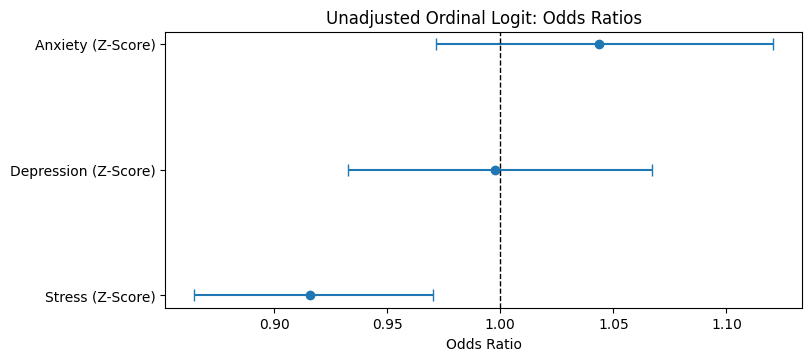

In [ ]:
res_unadjusted, df_unadjusted, terms_unadjusted = fit_ordinal_logit(
    df=mhp_dataset,
    outcome=OUTCOME_COL,
    predictors=Z_SCORE_COLS,
)

print(f"N (unadjusted) = {len(df_unadjusted)}")
display(res_unadjusted.summary())

or_unadjusted = tidy_or_table(
    result=res_unadjusted, feature_names=terms_unadjusted, clean_labels=CLEAN_LABELS
)

display(
    or_unadjusted.style.format(
        {
            "coef_log_odds": "{:.3f}",
            "odds_ratio": "{:.3f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
            "p_value": "{:.4f}",
        }
    )
)

plot_or_forest(
    or_table=or_unadjusted,
    title="Unadjusted Ordinal Logit: Odds Ratios",
    save_name="ordinal_unadjusted_forest.svg",
    focus_terms=Z_SCORE_COLS,
)

### ordinal logistic regression with control variables `+ department + academic_year + gender`


N (adjusted) = 2371


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                      y   Log-Likelihood:                -3758.7
Model:                   OrderedModel   AIC:                             7571.
Method:            Maximum Likelihood   BIC:                             7727.
Date:                Fri, 01 May 2026                                         
Time:                        20:03:45                                         
No. Observations:                2371                                         
Df Residuals:                    2344                                         
Df Model:                          22                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
stress_z_score                  -0.0884      0.030     -2.935      0.003      -0.147      -0.029
anxiety_z_score                  0.0216      0.037      0.588      0.556      -0.050       0.093
depression_z_score              -0.0054      0.035     -0.156      0.876      -0.073       0.063
department_business             -0.5634      0.142     -3.980      0.000      -0.841      -0.286
department_eng_civil            -0.4714      0.186     -2.535      0.011      -0.836      -0.107
department_eng_cs               -0.2587      0.114     -2.274      0.023      -0.482      -0.036
department_eng_eee              -0.1359      0.145     -0.935      0.350      -0.421       0.149
department_eng_mech             -0.6134      0.171     -3.597      0.000      -0.948      -0.279
department_eng_other            -0.9772      0.526     -1.857      0.063      -2.009       0.054
department_env_life_sciences    -0.3469      0.186     -1.869      0.062      -0.711       0.017
department_law                   6.4857   1660.365      0.004      0.997   -3247.770    3260.742
department_liberal_arts          0.1824      1.046      0.174      0.861      -1.867       2.232
department_not_recorded         -0.1582      0.124     -1.278      0.201      -0.401       0.084
department_other                -0.3891      0.159     -2.441      0.015      -0.701      -0.077
department_pharmacy              0.3057      0.743      0.412      0.681      -1.150       1.761
academic_year_first              0.4342      0.515      0.843      0.399      -0.575       1.443
academic_year_second             0.9606      0.515      1.864      0.062      -0.050       1.971
academic_year_third              0.8237      0.514      1.602      0.109      -0.184       1.831
academic_year_fourth             0.7280      0.515      1.413      0.158      -0.282       1.738
academic_year_other              0.6109      0.518      1.180      0.238      -0.404       1.626
gender_male                     -0.0868      0.048     -1.809      0.070      -0.181       0.007
gender_other                     0.2374      0.334      0.710      0.478      -0.418       0.893
0/1                             -1.1052      0.526     -2.102      0.036      -2.136      -0.075
1/2                             -1.3479      0.099    -13.589      0.000      -1.542      -1.154
2/3                             -0.3116      0.043     -7.319      0.000      -0.395      -0.228
3/4                             -0.2585      0.034     -7.715      0.000      -0.324      -0.193
4/5                             -0.0751      0.035     -2.173      0.030      -0.143      -0.007
================================================================================================
"""

/Users/manuel/Repositories/9th_sem/data7001/data7001_group15_project/mhp/utils.py:248: RuntimeWarning: overflow encountered in exp
  "ci_high": np.exp(conf.loc[slope_idx, 1].values),


,term,coef_log_odds,odds_ratio,ci_low,ci_high,p_value,label
0,department_business,-0.563,0.569,0.431,0.751,0.0001,department_business
1,department_eng_mech,-0.613,0.542,0.388,0.756,0.0003,department_eng_mech
2,stress_z_score,-0.088,0.915,0.863,0.971,0.0033,Stress (Z-Score)
3,department_eng_civil,-0.471,0.624,0.433,0.899,0.0112,department_eng_civil
4,department_other,-0.389,0.678,0.496,0.926,0.0146,department_other
5,department_eng_cs,-0.259,0.772,0.618,0.965,0.0229,department_eng_cs
6,department_env_life_sciences,-0.347,0.707,0.491,1.017,0.0616,department_env_life_sciences
7,academic_year_second,0.961,2.613,0.952,7.177,0.0624,academic_year_second
8,department_eng_other,-0.977,0.376,0.134,1.056,0.0633,department_eng_other
9,gender_male,-0.087,0.917,0.835,1.007,0.0704,gender_male


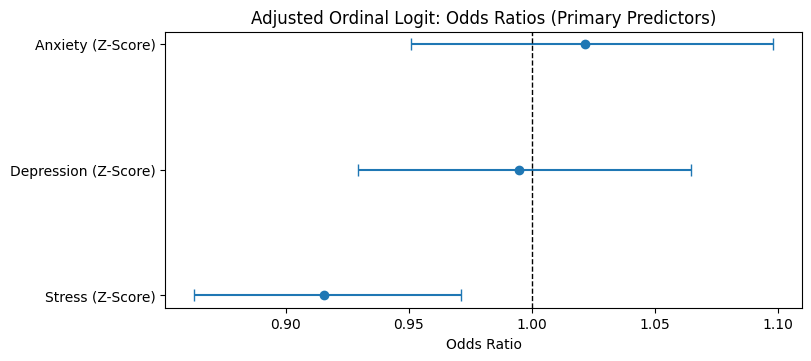

In [6]:
res_adjusted, df_adjusted, terms_adjusted = fit_ordinal_logit(
    df=mhp_dataset, outcome=OUTCOME_COL, predictors=Z_SCORE_COLS, controls=CONTROL_COLS
)

print(f"N (adjusted) = {len(df_adjusted)}")
display(res_adjusted.summary())

or_adjusted = tidy_or_table(
    result=res_adjusted, feature_names=terms_adjusted, clean_labels=CLEAN_LABELS
)

display(
    or_adjusted.style.format(
        {
            "coef_log_odds": "{:.3f}",
            "odds_ratio": "{:.3f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
            "p_value": "{:.4f}",
        }
    )
)

plot_or_forest(
    or_table=or_adjusted,
    title="Adjusted Ordinal Logit: Odds Ratios (Primary Predictors)",
    save_name="ordinal_adjusted_forest.svg",
    focus_terms=Z_SCORE_COLS,
)

In [7]:
comp = (
    or_unadjusted.set_index("term")[["odds_ratio", "ci_low", "ci_high", "p_value"]]
    .rename(
        columns={
            "odds_ratio": "OR_unadjusted",
            "ci_low": "CI_low_unadjusted",
            "ci_high": "CI_high_unadjusted",
            "p_value": "p_unadjusted",
        }
    )
    .join(
        or_adjusted.set_index("term")[
            ["odds_ratio", "ci_low", "ci_high", "p_value"]
        ].rename(
            columns={
                "odds_ratio": "OR_adjusted",
                "ci_low": "CI_low_adjusted",
                "ci_high": "CI_high_adjusted",
                "p_value": "p_adjusted",
            }
        ),
        how="left",
    )
    .loc[Z_SCORE_COLS]
    .reset_index()
)

comp["label"] = comp["term"].map(CLEAN_LABELS).fillna(comp["term"])

display(
    comp.style.format(
        {
            "OR_unadjusted": "{:.3f}",
            "CI_low_unadjusted": "{:.3f}",
            "CI_high_unadjusted": "{:.3f}",
            "p_unadjusted": "{:.4f}",
            "OR_adjusted": "{:.3f}",
            "CI_low_adjusted": "{:.3f}",
            "CI_high_adjusted": "{:.3f}",
            "p_adjusted": "{:.4f}",
        }
    )
)

,term,OR_unadjusted,CI_low_unadjusted,CI_high_unadjusted,p_unadjusted,OR_adjusted,CI_low_adjusted,CI_high_adjusted,p_adjusted,label
0,stress_z_score,0.916,0.865,0.970,0.0029,0.915,0.863,0.971,0.0033,Stress (Z-Score)
1,anxiety_z_score,1.043,0.972,1.120,0.2421,1.022,0.951,1.098,0.5563,Anxiety (Z-Score)
2,depression_z_score,0.998,0.933,1.067,0.9454,0.995,0.929,1.065,0.8764,Depression (Z-Score)


### separate adjusted ordinal models (one condition at a time)

In [8]:
separate_rows: list[pd.DataFrame] = []

for predictor in Z_SCORE_COLS:
    res_i, df_i, terms_i = fit_ordinal_logit(
        df=mhp_dataset,
        outcome=OUTCOME_COL,
        predictors=[predictor],
        controls=CONTROL_COLS,
    )

    or_i = tidy_or_table(
        result=res_i,
        feature_names=terms_i,
        clean_labels=CLEAN_LABELS,
    )

    # keep just the focal predictor row
    focal = or_i[or_i["term"] == predictor].copy()
    focal["model"] = f"{predictor} + controls"
    separate_rows.append(focal)

separate_tbl = pd.concat(separate_rows, ignore_index=True)
display(
    separate_tbl[
        ["model", "label", "odds_ratio", "ci_low", "ci_high", "p_value"]
    ].style.format(
        {
            "odds_ratio": "{:.3f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
            "p_value": "{:.4f}",
        }
    )
)

/Users/manuel/Repositories/9th_sem/data7001/data7001_group15_project/mhp/utils.py:248: RuntimeWarning: overflow encountered in exp
  "ci_high": np.exp(conf.loc[slope_idx, 1].values),


,model,label,odds_ratio,ci_low,ci_high,p_value
0,stress_z_score + controls,Stress (Z-Score),0.924,0.885,0.966,0.0004
1,anxiety_z_score + controls,Anxiety (Z-Score),0.961,0.921,1.004,0.0731
2,depression_z_score + controls,Depression (Z-Score),0.958,0.918,1.000,0.0515


### multicollinearity diagnostic (vif)

In [12]:
vif_df = df_adjusted[Z_SCORE_COLS].astype(float).copy()

vif_tbl = pd.DataFrame(
    {
        "term": vif_df.columns,
        "vif": [
            variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])
        ],
    }
)
vif_tbl["label"] = vif_tbl["term"].map(CLEAN_LABELS).fillna(vif_tbl["term"])
display(vif_tbl.style.format({"vif": "{:.3f}"}))

,term,vif,label
0,stress_z_score,1.889,Stress (Z-Score)
1,anxiety_z_score,2.891,Anxiety (Z-Score)
2,depression_z_score,2.581,Depression (Z-Score)


### pca-based latent distress model


In [11]:
pca_df = build_analysis_df(
    df=mhp_dataset, outcome=OUTCOME_COL, predictors=Z_SCORE_COLS, controls=CONTROL_COLS
).copy()

X_mh = pca_df[Z_SCORE_COLS].astype(float).values
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X_mh).ravel()

pca_df["mh_distress_pc1"] = pc1

res_pc1, df_pc1, terms_pc1 = fit_ordinal_logit(
    df=pca_df,
    outcome=OUTCOME_COL,
    predictors=["mh_distress_pc1"],
    controls=CONTROL_COLS,
)

or_pc1 = tidy_or_table(
    result=res_pc1,
    feature_names=terms_pc1,
    clean_labels={"mh_distress_pc1": "Mental Health Distress (PC1)"},
)

print(f"PC1 explained variance ratio: {pca.explained_variance_ratio_[0]:.3f}")
display(
    or_pc1.style.format(
        {
            "coef_log_odds": "{:.3f}",
            "odds_ratio": "{:.3f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
            "p_value": "{:.4f}",
        }
    )
)

PC1 explained variance ratio: 0.790


,term,coef_log_odds,odds_ratio,ci_low,ci_high,p_value,label
0,department_business,-0.562,0.570,0.432,0.753,0.0001,department_business
1,department_eng_mech,-0.622,0.537,0.385,0.750,0.0003,department_eng_mech
2,mh_distress_pc1,-0.038,0.963,0.936,0.990,0.0078,Mental Health Distress (PC1)
3,department_eng_civil,-0.486,0.615,0.427,0.885,0.0089,department_eng_civil
4,department_other,-0.398,0.672,0.492,0.918,0.0125,department_other
5,department_eng_cs,-0.250,0.779,0.623,0.973,0.0279,department_eng_cs
6,department_env_life_sciences,-0.358,0.699,0.486,1.005,0.0535,department_env_life_sciences
7,academic_year_second,0.955,2.599,0.947,7.137,0.0638,academic_year_second
8,department_eng_other,-0.957,0.384,0.137,1.075,0.0685,department_eng_other
9,gender_male,-0.083,0.920,0.838,1.011,0.0818,gender_male


### one-way ANOVA by condition level (`stress_level`, `anxiety_level`, `depression_level`)

,label,F_stat,p_value,eta_sq,n_groups,n
0,stress_level,4.619,0.0003376,0.010,6,2371
1,anxiety_level,1.563,0.1671,0.003,6,2371
2,depression_level,2.129,0.05923,0.004,6,2371


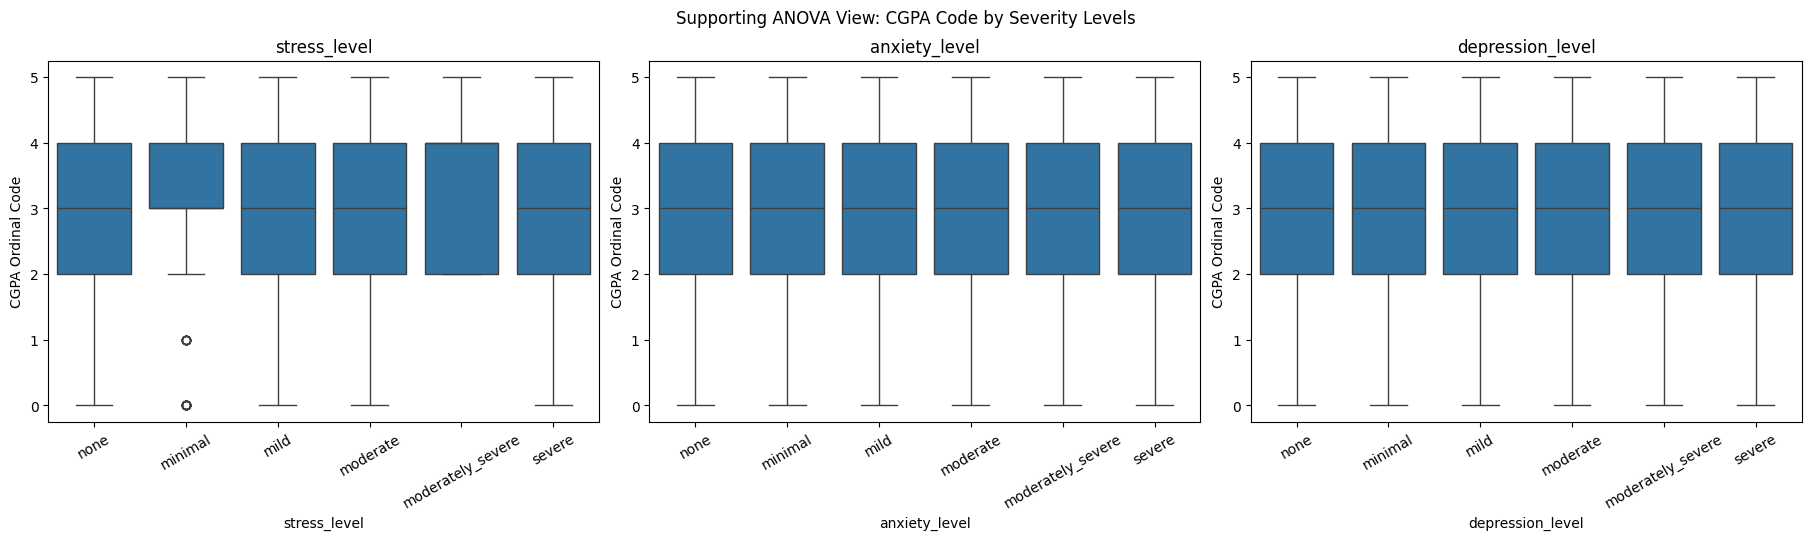

In [17]:
anova_df = mhp_dataset[[OUTCOME_COL, *SEVERITY_COLS]].dropna().copy()
anova_df["cgpa_code"] = anova_df[OUTCOME_COL].cat.codes.astype(float)

anova_rows: list[dict[str, float | int | str]] = []

for sev_col in SEVERITY_COLS:
    groups = [
        g["cgpa_code"].to_numpy() for _, g in anova_df.groupby(sev_col, observed=True)
    ]

    f_stat, p_value = f_oneway(*groups)

    # eta-squared effect size from one-way ANOVA F-stat
    k = len(groups)
    n = len(anova_df)
    eta_sq = (f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k)) if n > k else np.nan

    anova_rows.append(
        {
            "condition": sev_col,
            "F_stat": float(f_stat),
            "p_value": float(p_value),
            "eta_sq": float(eta_sq),
            "n_groups": int(k),
            "n": int(n),
        }
    )

anova_tbl = pd.DataFrame(anova_rows)
anova_tbl["label"] = (
    anova_tbl["condition"].map(CLEAN_LABELS).fillna(anova_tbl["condition"])
)

display(
    anova_tbl[["label", "F_stat", "p_value", "eta_sq", "n_groups", "n"]].style.format(
        {
            "F_stat": "{:.3f}",
            "p_value": "{:.4g}",
            "eta_sq": "{:.3f}",
        }
    )
)

fig, axes = plt.subplots(
    1, len(SEVERITY_COLS), figsize=(18, 5), constrained_layout=True
)

for ax, sev_col in zip(axes, SEVERITY_COLS):
    sns.boxplot(data=anova_df, x=sev_col, y="cgpa_code", ax=ax)
    ax.set_title(CLEAN_LABELS.get(sev_col, sev_col))
    ax.set_ylabel("CGPA Ordinal Code")
    ax.tick_params(axis="x", labelrotation=30)

fig.suptitle("Supporting ANOVA View: CGPA Code by Severity Levels", y=1.05)
fig.savefig(PLOTS / "anova_boxplots.svg", format="svg", bbox_inches="tight")
plt.show()

### chi-square independence test `severity x cgpa` (`stress_level`, `anxiety_level`, `depression_level`)

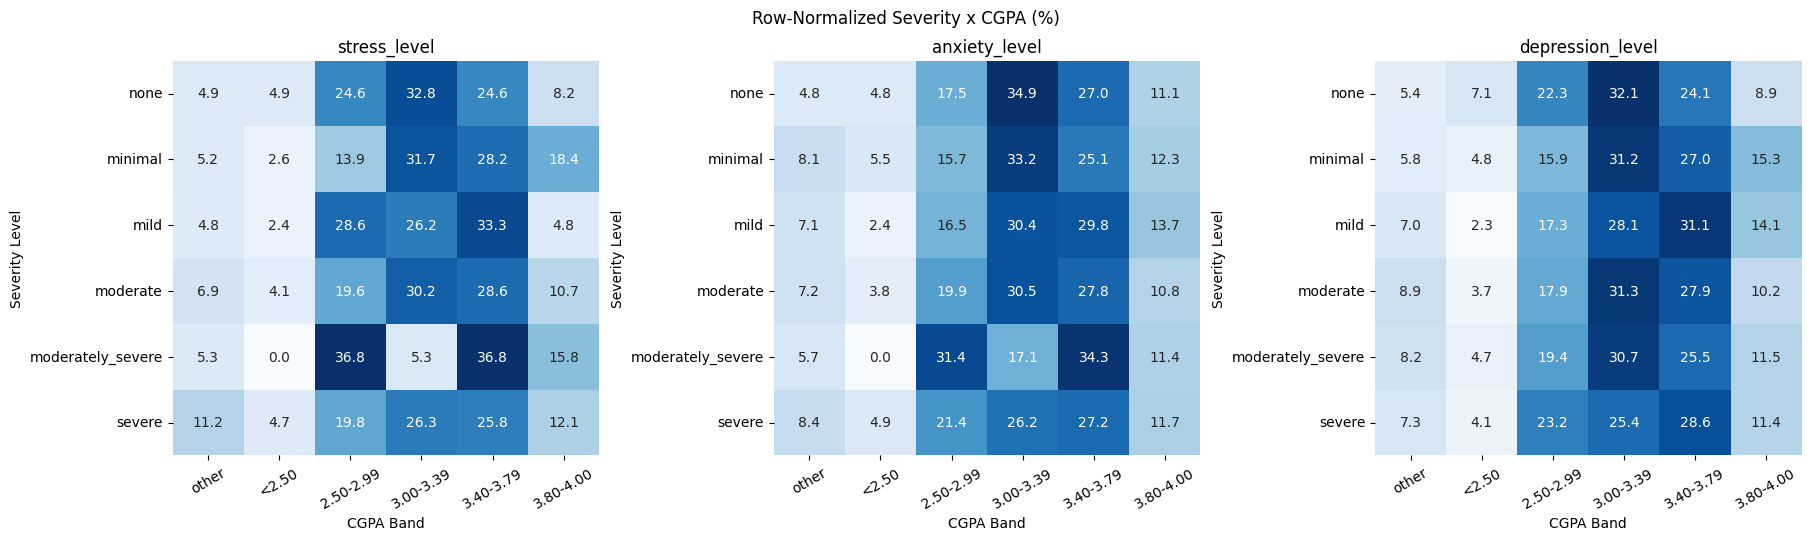

,label,chi2,dof,p_value,cramers_v,n
0,stress_level,53.25,25,0.0008304,0.067,2379
1,anxiety_level,29.35,25,0.2494,0.050,2371
2,depression_level,31.83,25,0.163,0.052,2379


In [20]:
chi_rows: list[dict[str, float | int | str]] = []

fig, axes = plt.subplots(
    1, len(SEVERITY_COLS), figsize=(18, 5), constrained_layout=True
)

for ax, sev_col in zip(axes, SEVERITY_COLS):
    chi_df = mhp_dataset[[sev_col, OUTCOME_COL]].dropna().copy()

    ct = pd.crosstab(chi_df[sev_col], chi_df[OUTCOME_COL], dropna=False)
    chi2, p_value, dof, _ = chi2_contingency(ct)
    v = cramers_v_from_table(ct)

    chi_rows.append(
        {
            "condition": sev_col,
            "chi2": float(chi2),
            "dof": int(dof),
            "p_value": float(p_value),
            "cramers_v": float(v),
            "n": int(ct.to_numpy().sum()),
        }
    )

    # row-normalized heatmap (%)
    prop = ct.div(ct.sum(axis=1), axis=0) * 100
    sns.heatmap(prop, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(CLEAN_LABELS.get(sev_col, sev_col))
    ax.set_xlabel("CGPA Band")
    ax.set_ylabel("Severity Level")
    ax.tick_params(axis="x", labelrotation=30)

fig.suptitle("Row-Normalized Severity x CGPA (%)", y=1.05)
fig.savefig(PLOTS / "chisquare_heatmaps.svg", format="svg", bbox_inches="tight")
plt.show()

chi_tbl = pd.DataFrame(chi_rows)
chi_tbl["label"] = chi_tbl["condition"].map(CLEAN_LABELS).fillna(chi_tbl["condition"])

display(
    chi_tbl[["label", "chi2", "dof", "p_value", "cramers_v", "n"]].style.format(
        {
            "chi2": "{:.2f}",
            "p_value": "{:.4g}",
            "cramers_v": "{:.3f}",
        }
    )
)